# Laboratorio: Regresión con Bike Sharing

## 1. Importación de Librerías

In [1]:
# librerias
import os
import numpy as np
import pandas as pd
from matplotlib import pyplot
import matplotlib.pyplot as plt

# montar drive
from google.colab import drive
drive.mount('/content/gdrive')

# cargar dataset
data = pd.read_csv(
    '/content/gdrive/MyDrive/Colab Notebooks/machine learning/datasets/hour.csv'
)

print('dimensiones:', data.shape)
print('\ncolumnas:')
print(data.columns.tolist())

print('\nprimeros registros:')
display(data.head())

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).
dimensiones: (17379, 17)

columnas:
['instant', 'dteday', 'season', 'yr', 'mnth', 'hr', 'holiday', 'weekday', 'workingday', 'weathersit', 'temp', 'atemp', 'hum', 'windspeed', 'casual', 'registered', 'cnt']

primeros registros:


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.24,0.2879,0.81,0.0,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.22,0.2727,0.80,0.0,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.22,0.2727,0.80,0.0,5,27,32
3,4,2011-01-01,1,0,1,3,0,6,0,1,0.24,0.2879,0.75,0.0,3,10,13
4,5,2011-01-01,1,0,1,4,0,6,0,1,0.24,0.2879,0.75,0.0,0,1,1


## 2. Carga y Exploración del Dataset

In [2]:
X = data[
    [
        'season',
        'yr',
        'mnth',
        'hr',
        'holiday',
        'weekday',
        'workingday',
        'weathersit',
        'temp',
        'atemp',
        'hum',
        'windspeed'
    ]
].values

In [3]:
y = data['cnt'].values

In [4]:
print('Tamaño de X:', X.shape)
print('Tamaño de y:', y.shape)

Tamaño de X: (17379, 12)
Tamaño de y: (17379,)


## 3. Normalización de las características

In [5]:
# normalizacion
def featureNormalize(X):
    X_norm = X.copy()
    mu = np.mean(X, axis=0)
    sigma = np.std(X, axis=0)

    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

# normalizar caracteristicas
X_norm, mu, sigma = featureNormalize(X)

print('media:')
print(mu)

print('\ndesviacion estandar:')
print(sigma)

print('\nprimeros 5 registros normalizados:')
print(X_norm[:5])

media:
[ 2.50163991  0.50256056  6.53777548 11.54675183  0.02877036  3.00368261
  0.68272052  1.42528339  0.49698717  0.4757751   0.62722884  0.19009761]

desviacion estandar:
[1.10688629 0.49999344 3.43867678 6.91420616 0.16716047 2.00571375
 0.46541724 0.63933848 0.19255058 0.17184527 0.19292428 0.12233671]

primeros 5 registros normalizados:
[[-1.3566343  -1.0051343  -1.61043792 -1.67000398 -0.1721122   1.49389084
  -1.46689994 -0.66519285 -1.33464759 -1.0932806   0.9473725  -1.55388851]
 [-1.3566343  -1.0051343  -1.61043792 -1.52537422 -0.1721122   1.49389084
  -1.46689994 -0.66519285 -1.4385164  -1.18173227  0.89553869 -1.55388851]
 [-1.3566343  -1.0051343  -1.61043792 -1.38074446 -0.1721122   1.49389084
  -1.46689994 -0.66519285 -1.4385164  -1.18173227  0.89553869 -1.55388851]
 [-1.3566343  -1.0051343  -1.61043792 -1.23611469 -0.1721122   1.49389084
  -1.46689994 -0.66519285 -1.33464759 -1.0932806   0.63636966 -1.55388851]
 [-1.3566343  -1.0051343  -1.61043792 -1.09148493 -0.1721

## 4. Agregar el término de intersección

In [6]:
m = y.size

# agregar termino de interseccion
X_modelo = np.concatenate(
    [np.ones((m, 1)), X_norm],
    axis=1
)

print('dimensiones de x_modelo:', X_modelo.shape)

dimensiones de x_modelo: (17379, 13)


## 5. Crear la función de costo

In [7]:
# funcion de costo
def computeCostMulti(X, y, theta):
    m = y.shape[0]

    # hipotesis y calculo de costo
    h = np.dot(X, theta)
    J = (1 / (2 * m)) * np.sum(np.square(h - y))

    return J

## 6. Descenso por el gradiente

In [8]:
# descenso por el gradiente
def gradientDescentMulti(X, y, theta, alpha, num_iters):
    m = y.shape[0]
    theta = theta.copy()
    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

## 7. Separar Entrenamiento y Validación

In [9]:
# division entrenamiento y validacion
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print('tamano entrenamiento:')
print(X_train.shape, y_train.shape)

print('\ntamano validacion:')
print(X_val.shape, y_val.shape)

tamano entrenamiento:
(13903, 12) (13903,)

tamano validacion:
(3476, 12) (3476,)


## 8. Normalizar Correctamente

In [10]:
# normalizacion
X_train_norm, mu, sigma = featureNormalize(X_train)

X_val_norm = (X_val - mu) / sigma

print('primeros 5 registros entrenamiento:')
print(X_train_norm[:5])

print('\nprimeros 5 registros validacion:')
print(X_val_norm[:5])

primeros 5 registros entrenamiento:
[[-1.36363715e+00 -1.00410827e+00 -1.61573901e+00 -8.06093561e-02
  -1.71891829e-01  1.49248305e+00 -1.45628403e+00 -6.66892193e-01
  -1.54083688e+00 -1.62031134e+00 -3.99448801e-01  2.78668674e-01]
 [ 1.34693531e+00 -1.00410827e+00  1.00297496e+00  9.32169258e-01
  -1.71891829e-01 -4.96302289e-01  6.86679231e-01 -6.66892193e-01
   1.17112099e-01  1.38228328e-01 -1.07374273e+00 -6.97713579e-01]
 [ 1.34693531e+00 -1.00410827e+00  1.58491140e+00 -1.23807063e+00
  -1.71891829e-01  8.94045052e-04  6.86679231e-01  2.46388686e+00
  -1.93753334e-01 -1.25842810e-01  1.93464557e+00  2.78668674e-01]
 [-4.60112998e-01 -1.00410827e+00 -7.42834349e-01  9.32169258e-01
  -1.71891829e-01 -1.49069496e+00 -1.45628403e+00  8.98497333e-01
  -1.93753334e-01 -1.25842810e-01 -1.64429913e+00 -1.55225249e+00]
 [-1.36363715e+00 -1.00410827e+00  1.58491140e+00 -8.04022651e-01
  -1.71891829e-01 -1.49069496e+00 -1.45628403e+00 -6.66892193e-01
  -1.54083688e+00 -1.44445738e+00  6

## 9. Agregar la Columna de Unos

In [11]:
# termino de interseccion
m_train = y_train.size
m_val = y_val.size

X_train_modelo = np.concatenate(
    [np.ones((m_train, 1)), X_train_norm],
    axis=1
)

X_val_modelo = np.concatenate(
    [np.ones((m_val, 1)), X_val_norm],
    axis=1
)

print('x_train_modelo:', X_train_modelo.shape)
print('x_val_modelo:', X_val_modelo.shape)

x_train_modelo: (13903, 13)
x_val_modelo: (3476, 13)


## 10. Volver a Entrenar el Modelo

In [12]:
# entrenamiento
alpha = 0.01
num_iters = 10000

theta = np.zeros(X_train_modelo.shape[1])

theta, J_history = gradientDescentMulti(
    X_train_modelo,
    y_train,
    theta,
    alpha,
    num_iters
)

print('theta:')
print(theta)

print('\ncosto final:')
print(J_history[-1])

theta:
[190.5770697   22.71249461  41.41709947   0.40669576  52.97227226
  -4.03799396   3.5586407    1.81574847  -2.21155978  21.66841204
  32.76316156 -38.42872683   4.12420549]

costo final:
10146.401096126192


## 11. Gráfico del Costo

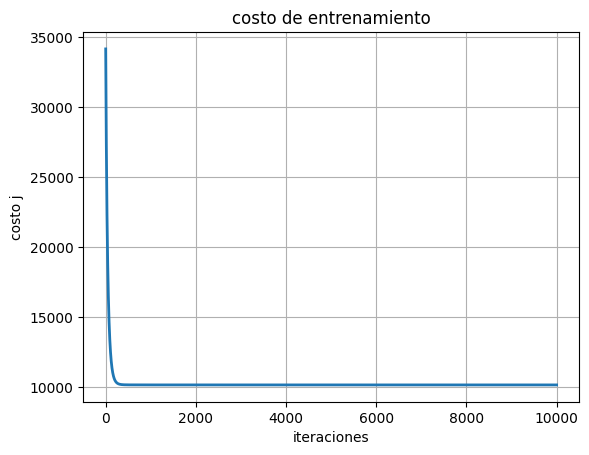

In [13]:
# curva de costo de entrenamiento
pyplot.plot(
    np.arange(len(J_history)),
    J_history,
    lw=2
)

pyplot.xlabel('iteraciones')
pyplot.ylabel('costo j')
pyplot.title('costo de entrenamiento')
pyplot.grid()

pyplot.show()

## 12. Evaluar el Modelo en Entrenamiento y Validación

In [14]:
# metricas entrenamiento
pred_train = np.dot(X_train_modelo, theta)

mse_train = np.mean((pred_train - y_train) ** 2)
rmse_train = np.sqrt(mse_train)

print('resultados entrenamiento:')
print('mse:', mse_train)
print('rmse:', rmse_train)

resultados entrenamiento:
mse: 20292.802192252384
rmse: 142.45280689495866


In [15]:
# metricas validacion
pred_val = np.dot(X_val_modelo, theta)

mse_val = np.mean((pred_val - y_val) ** 2)
rmse_val = np.sqrt(mse_val)

print('\nresultados validacion:')
print('mse:', mse_val)
print('rmse:', rmse_val)


resultados validacion:
mse: 19382.522493734858
rmse: 139.2211280436086


## 13. Revisar algunas Predicciones de Validación

In [16]:
# comparacion
print('primeras 10 predicciones validacion:')
print(pred_val[:10])

print('\nprimeros 10 valores reales:')
print(y_val[:10])

primeras 10 predicciones validacion:
[450.9720796  204.89036295  57.44107947 383.4785354  -19.95896742
   7.05101273 344.47370325  25.10208115 122.11386149  99.18797582]

primeros 10 valores reales:
[425  88   4 526  13  32 706  26   2  21]


In [17]:
# resultados regresion lineal multivariable
print('=== regresion lineal multivariable ===')
print('mse entrenamiento:', mse_train)
print('rmse entrenamiento:', rmse_train)
print('mse validacion:', mse_val)
print('rmse validacion:', rmse_val)

print('\nprimeras 10 predicciones:')
for real, pred in zip(y_val[:10], pred_val[:10]):
    print(f'real: {real:>6.0f} | prediccion: {pred:>10.2f}')

=== regresion lineal multivariable ===
mse entrenamiento: 20292.802192252384
rmse entrenamiento: 142.45280689495866
mse validacion: 19382.522493734858
rmse validacion: 139.2211280436086

primeras 10 predicciones:
real:    425 | prediccion:     450.97
real:     88 | prediccion:     204.89
real:      4 | prediccion:      57.44
real:    526 | prediccion:     383.48
real:     13 | prediccion:     -19.96
real:     32 | prediccion:       7.05
real:    706 | prediccion:     344.47
real:     26 | prediccion:      25.10
real:      2 | prediccion:     122.11
real:     21 | prediccion:      99.19


## 14. Regresión Polinómica

In [18]:
# regresion polinomica
X_train_poly = np.concatenate(
    [X_train, X_train ** 2],
    axis=1
)

X_val_poly = np.concatenate(
    [X_val, X_val ** 2],
    axis=1
)

X_train_poly, mu_poly, sigma_poly = featureNormalize(X_train_poly)
X_val_poly = (X_val_poly - mu_poly) / sigma_poly

X_train_poly = np.concatenate(
    [np.ones((X_train_poly.shape[0], 1)), X_train_poly],
    axis=1
)

X_val_poly = np.concatenate(
    [np.ones((X_val_poly.shape[0], 1)), X_val_poly],
    axis=1
)

theta_poly = np.zeros(X_train_poly.shape[1])

theta_poly, J_history_poly = gradientDescentMulti(
    X_train_poly,
    y_train,
    theta_poly,
    0.01,
    10000
)

pred_poly = np.dot(X_val_poly, theta_poly)

mse_poly = np.mean((pred_poly - y_val) ** 2)
rmse_poly = np.sqrt(mse_poly)

print('=== regresion polinomica ===')
print('mse validacion:', mse_poly)
print('rmse validacion:', rmse_poly)

=== regresion polinomica ===
mse validacion: 16295.173332775712
rmse validacion: 127.65254926077941


In [19]:
## 15. Gráfico de Costo Polinómico

## 16. Ecuación de la Normal

In [20]:
# ecuacion de la normal
def normalEqn(X, y):
    theta = np.zeros(X.shape[1])
    theta = np.dot(
        np.dot(np.linalg.inv(np.dot(X.T, X)), X.T),
        y
    )
    return theta

# calculo de parametros y predicciones
theta_normal = normalEqn(X_train_modelo, y_train)
pred_normal = np.dot(X_val_modelo, theta_normal)

# metricas
mse_normal = np.mean((pred_normal - y_val) ** 2)
rmse_normal = np.sqrt(mse_normal)

print('=== ecuacion de la normal ===')
print('mse validacion:', mse_normal)
print('rmse validacion:', rmse_normal)

=== ecuacion de la normal ===
mse validacion: 19379.828367651728
rmse validacion: 139.2114519989348


## 17. Visualización del Costo - Ecuación de la Normal

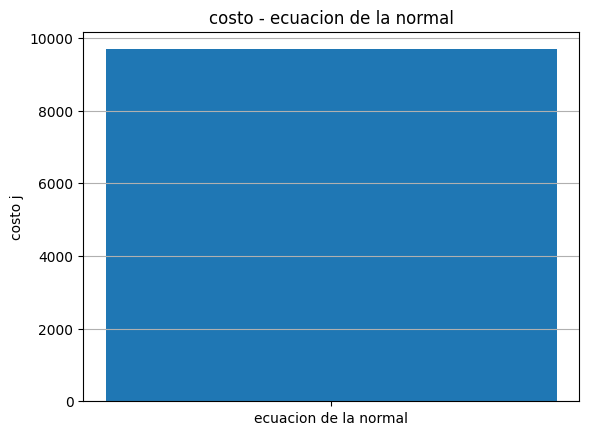

In [21]:
# costo ecuacion de la normal
costo_normal = computeCostMulti(
    X_val_modelo,
    y_val,
    theta_normal
)

# grafico de barras
pyplot.bar(
    ['ecuacion de la normal'],
    [costo_normal]
)

pyplot.ylabel('costo j')
pyplot.title('costo - ecuacion de la normal')
pyplot.grid(axis='y')
pyplot.show()

In [22]:
# ==========================================
# COMPARACIÓN DE LOS TRES MODELOS
# ==========================================

resultados = pd.DataFrame({
    'Modelo': [
        'Regresión Lineal Multivariable',
        'Regresión Polinómica',
        'Ecuación de la Normal'
    ],
    'MSE': [
        mse_val,
        mse_poly,
        mse_normal
    ],
    'RMSE': [
        rmse_val,
        rmse_poly,
        rmse_normal
    ]
})

display(resultados)

,Modelo,MSE,RMSE
0,Regresión Lineal Multivariable,19382.522494,139.221128
1,Regresión Polinómica,16295.173333,127.652549
2,Ecuación de la Normal,19379.828368,139.211452


In [23]:
# ==========================================
# 100 PREDICCIONES
# ==========================================

comparacion_100 = pd.DataFrame({
    'Real': y_val[:100],
    'Lineal': pred_val[:100],
    'Polinomica': pred_poly[:100],
    'Normal': pred_normal[:100]
})

display(comparacion_100)

,Real,Lineal,Polinomica,Normal
0,425,450.972080,415.288070,450.296525
1,88,204.890363,181.152671,204.674145
2,4,57.441079,8.891601,57.297891
3,526,383.478535,356.207967,383.363764
4,13,-19.958967,-140.349475,-20.341232
...,...,...,...,...
95,76,130.740756,166.222791,131.230731
96,177,123.276301,165.556998,123.306001
97,186,273.169484,299.767284,272.879249
98,4,27.374393,60.556607,27.019795
